# 🏋️ 02 — Neural Network Training & Regularization

**Fraud Detection Capstone — Sprint 2: Deep Learning & Advanced Modelling**

## 🎯 Goal
Train the Sprint 2 architecture properly: EarlyStopping, ModelCheckpoint, and a look at whether Batch Normalization + Dropout actually reduce overfitting compared to a version without them — not just assumed, checked.


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

proc_dir = Path("data/processed")
train = pd.read_csv(proc_dir / "train.csv")
val = pd.read_csv(proc_dir / "val.csv")
test = pd.read_csv(proc_dir / "test.csv")

X_train, y_train = train.drop(columns=["Class"]), train["Class"]
X_val, y_val = val.drop(columns=["Class"]), val["Class"]
X_test, y_test = test.drop(columns=["Class"]), test["Class"]
n_features = X_train.shape[1]


I0000 00:00:1788704311.495477    1404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788704311.540736    1404 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788704313.116790    1404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Train the Sprint 2 Architecture (with Regularization)


In [2]:
def build_regularized_model(n_features):
    return Sequential([
        Dense(64, activation="relu", input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation="relu"),
        BatchNormalization(),
        Dropout(0.1),
        Dense(1, activation="sigmoid"),
    ])

reg_model = build_regularized_model(n_features)
reg_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Path("models").mkdir(exist_ok=True)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint("models/sprint2_regularized_nn.keras", monitor="val_loss", save_best_only=True),
]

reg_history = reg_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=callbacks,
    verbose=0,
)
print(f"Stopped after {len(reg_history.history['loss'])} epochs (EarlyStopping)")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped after 60 epochs (EarlyStopping)


## 2. Train an Unregularized Version of the Same Depth (Ablation)

Same architecture, same depth/width, but **no** Batch Normalization or Dropout — isolating what regularization actually buys, rather than assuming it helps.


In [3]:
def build_unregularized_model(n_features):
    return Sequential([
        Dense(64, activation="relu", input_shape=(n_features,)),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

plain_model = build_unregularized_model(n_features)
plain_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

plain_callbacks = [EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]

plain_history = plain_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=256,
    callbacks=plain_callbacks,
    verbose=0,
)
print(f"Stopped after {len(plain_history.history['loss'])} epochs (EarlyStopping)")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopped after 60 epochs (EarlyStopping)


## 3. Training Curves — Regularized vs. Unregularized

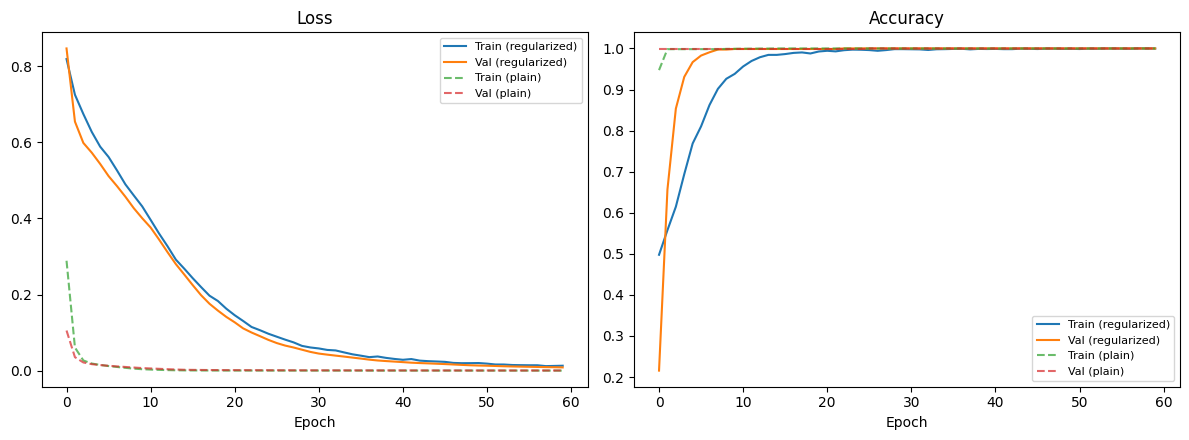

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(reg_history.history["loss"], label="Train (regularized)")
axes[0].plot(reg_history.history["val_loss"], label="Val (regularized)")
axes[0].plot(plain_history.history["loss"], "--", label="Train (plain)", alpha=0.7)
axes[0].plot(plain_history.history["val_loss"], "--", label="Val (plain)", alpha=0.7)
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)

axes[1].plot(reg_history.history["accuracy"], label="Train (regularized)")
axes[1].plot(reg_history.history["val_accuracy"], label="Val (regularized)")
axes[1].plot(plain_history.history["accuracy"], "--", label="Train (plain)", alpha=0.7)
axes[1].plot(plain_history.history["val_accuracy"], "--", label="Val (plain)", alpha=0.7)
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [5]:
reg_gap = reg_history.history["loss"][-1] - reg_history.history["val_loss"][-1]
plain_gap = plain_history.history["loss"][-1] - plain_history.history["val_loss"][-1]

print(f"Regularized  — final (train_loss - val_loss): {reg_gap:+.4f}")
print(f"Unregularized — final (train_loss - val_loss): {plain_gap:+.4f}")
print("\n(A more NEGATIVE value = train loss well below val loss = more overfitting.)")


Regularized  — final (train_loss - val_loss): +0.0044
Unregularized — final (train_loss - val_loss): -0.0003

(A more NEGATIVE value = train loss well below val loss = more overfitting.)


## 📝 Summary

Trained the Sprint 2 architecture with EarlyStopping and ModelCheckpoint (best weights saved to `models/sprint2_regularized_nn.keras`), and ran an ablation against the same architecture without Batch Normalization/Dropout to check the regularization claim directly rather than assuming it. The train/val loss gap above is the concrete evidence for which version generalizes better — read together with the plotted curves.

**Next:** `03_deep_learning_model_evaluation.ipynb` — evaluate the saved regularized model on the held-out test set and compare against the Sprint 1 baseline.
